In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
# If needed, change BASE_DIR to your Week7 folder manually
BASE_DIR = Path(r"c:\Users\admin\Desktop\RRcourse2026")
DATA_DIR = BASE_DIR / "Data"

COUNTRIES = ["Belgium", "Spain", "Poland"]
TASK_VARS = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]
TASK_LABEL = "NRCA"

# -----------------------------
# Load data
# -----------------------------
task_data = pd.read_csv(DATA_DIR / "onet_tasks.csv")

isco_dfs = []
for isco in range(1, 10):
    df = pd.read_excel(DATA_DIR / "Eurostat_employment_isco.xlsx", sheet_name=f"ISCO{isco}")
    df["ISCO"] = isco
    isco_dfs.append(df)

all_data = pd.concat(isco_dfs, ignore_index=True)

all_data.head()

,TIME,European Union - 28 countries (2013-2020),Belgium,Czechia,Denmark,Spain,Italy,Lithuania,Poland,Finland,Sweden,ISCO
0,2011-Q1,12850.9,279.0,223.5,57.6,879.8,896.0,120.0,963.5,137.2,232.6,1
1,2011-Q2,12834.2,304.7,226.2,58.2,911.6,897.0,118.9,918.4,135.8,236.0,1
2,2011-Q3,12763.1,348.8,227.3,107.5,881.4,840.1,107.0,913.8,123.5,238.5,1
3,2011-Q4,12668.1,347.9,230.3,74.1,888.2,764.9,107.8,935.9,106.6,246.1,1
4,2012-Q1,12197.3,304.0,231.1,50.6,848.8,762.2,107.5,952.5,102.5,249.8,1


In [7]:
# -----------------------------
# Employment shares
# -----------------------------
for country in COUNTRIES:
    all_data[f"total_{country}"] = all_data.groupby("TIME")[country].transform("sum")
    all_data[f"share_{country}"] = all_data[country] / all_data[f"total_{country}"]

all_data.head()

,TIME,European Union - 28 countries (2013-2020),Belgium,Czechia,Denmark,Spain,Italy,Lithuania,Poland,Finland,Sweden,ISCO,total_Belgium,share_Belgium,total_Spain,share_Spain,total_Poland,share_Poland
0,2011-Q1,12850.9,279.0,223.5,57.6,879.8,896.0,120.0,963.5,137.2,232.6,1,4391.5,0.063532,18169.2,0.048423,15027.1,0.064117
1,2011-Q2,12834.2,304.7,226.2,58.2,911.6,897.0,118.9,918.4,135.8,236.0,1,4472.2,0.068132,18373.4,0.049615,15245.5,0.060241
2,2011-Q3,12763.1,348.8,227.3,107.5,881.4,840.1,107.0,913.8,123.5,238.5,1,4428.3,0.078766,18241.4,0.048319,15353.6,0.059517
3,2011-Q4,12668.1,347.9,230.3,74.1,888.2,764.9,107.8,935.9,106.6,246.1,1,4473.3,0.077773,17896.2,0.049631,15260.8,0.061327
4,2012-Q1,12197.3,304.0,231.1,50.6,848.8,762.2,107.5,952.5,102.5,249.8,1,4426.3,0.068680,17509.0,0.048478,15055.5,0.063266


In [8]:
# -----------------------------
# Task data at 1-digit ISCO level
# -----------------------------
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[0].astype(int)

aggdata = (
    task_data
    .groupby("isco08_1dig", as_index=False)
    .mean(numeric_only=True)
)

combined = all_data.merge(aggdata, left_on="ISCO", right_on="isco08_1dig", how="left")

combined.head()

,TIME,European Union - 28 countries (2013-2020),Belgium,Czechia,Denmark,Spain,Italy,Lithuania,Poland,Finland,...,t_4C3b7,t_4C3d3,t_4C3b8_rev,t_4C1a2l_rev,t_4A4a5_rev,t_4A4a8_rev,t_4A1b2_rev,t_4A3a2_rev,t_4A3b4_rev,t_4A3b5_rev
0,2011-Q1,12850.9,279.0,223.5,57.6,879.8,896.0,120.0,963.5,137.2,...,3.265843,1.518102,1.567,1.208102,3.203343,2.898278,3.102407,3.865861,4.223907,4.270759
1,2011-Q2,12834.2,304.7,226.2,58.2,911.6,897.0,118.9,918.4,135.8,...,3.265843,1.518102,1.567,1.208102,3.203343,2.898278,3.102407,3.865861,4.223907,4.270759
2,2011-Q3,12763.1,348.8,227.3,107.5,881.4,840.1,107.0,913.8,123.5,...,3.265843,1.518102,1.567,1.208102,3.203343,2.898278,3.102407,3.865861,4.223907,4.270759
3,2011-Q4,12668.1,347.9,230.3,74.1,888.2,764.9,107.8,935.9,106.6,...,3.265843,1.518102,1.567,1.208102,3.203343,2.898278,3.102407,3.865861,4.223907,4.270759
4,2012-Q1,12197.3,304.0,231.1,50.6,848.8,762.2,107.5,952.5,102.5,...,3.265843,1.518102,1.567,1.208102,3.203343,2.898278,3.102407,3.865861,4.223907,4.270759


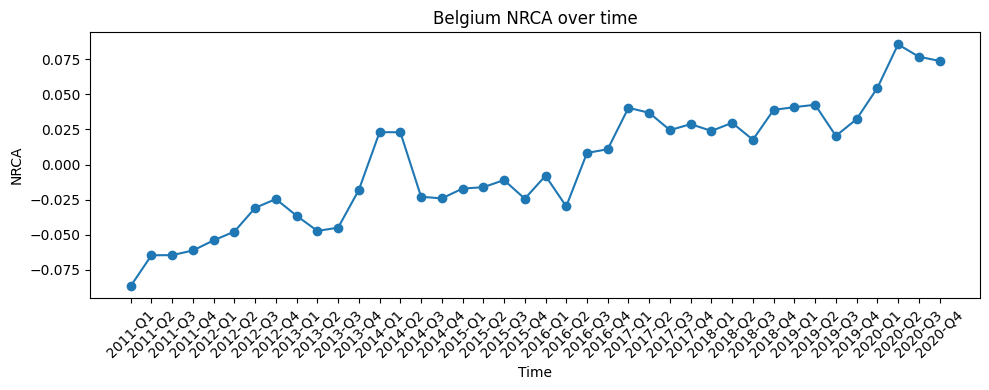

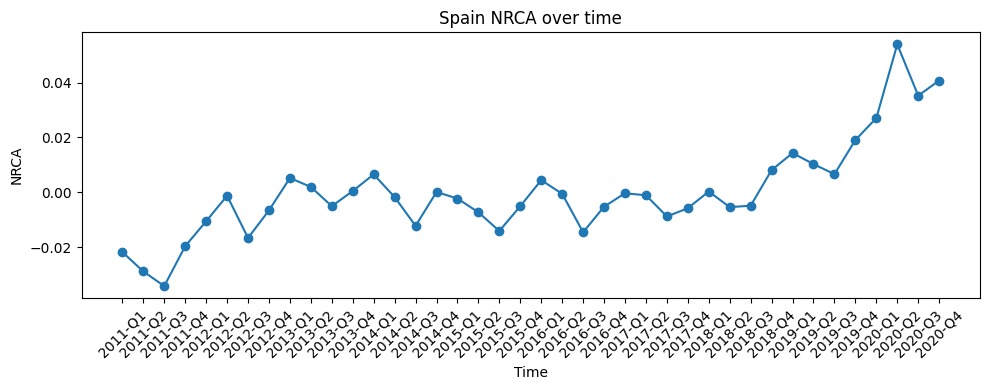

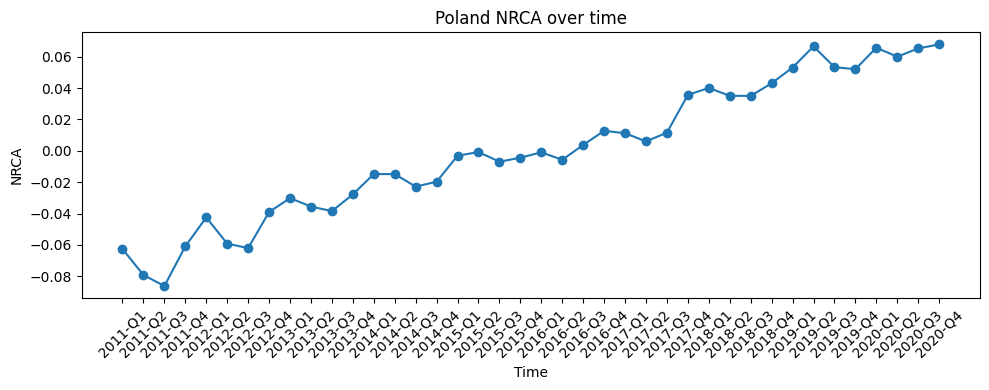

In [9]:
def weighted_zscore(values, weights):
    values = pd.Series(values, dtype=float)
    weights = pd.Series(weights, dtype=float)

    mask = values.notna() & weights.notna()
    v = values[mask]
    w = weights[mask]

    weighted_mean = np.average(v, weights=w)
    weighted_sd = np.sqrt(np.average((v - weighted_mean) ** 2, weights=w))

    result = pd.Series(np.nan, index=values.index)
    result.loc[mask] = (v - weighted_mean) / weighted_sd
    return result


# -----------------------------
# Standardize each task for each country
# -----------------------------
for task in TASK_VARS:
    for country in COUNTRIES:
        combined[f"std_{country}_{task}"] = weighted_zscore(
            combined[task],
            combined[f"share_{country}"]
        )

# -----------------------------
# Build NRCA index
# -----------------------------
for country in COUNTRIES:
    std_task_cols = [f"std_{country}_{task}" for task in TASK_VARS]
    combined[f"{country}_{TASK_LABEL}"] = combined[std_task_cols].sum(axis=1)
    combined[f"std_{country}_{TASK_LABEL}"] = weighted_zscore(
        combined[f"{country}_{TASK_LABEL}"],
        combined[f"share_{country}"]
    )

# -----------------------------
# Country-level time series
# -----------------------------
agg_results = {}

for country in COUNTRIES:
    temp = combined.copy()
    temp["weighted_index"] = temp[f"std_{country}_{TASK_LABEL}"] * temp[f"share_{country}"]

    agg_results[country] = (
        temp.groupby("TIME", as_index=False)["weighted_index"]
        .sum()
        .rename(columns={"weighted_index": TASK_LABEL})
    )

# -----------------------------
# Plot
# -----------------------------
for country, df_country in agg_results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(df_country["TIME"], df_country[TASK_LABEL], marker="o")
    plt.title(f"{country} {TASK_LABEL} over time")
    plt.xlabel("Time")
    plt.ylabel(TASK_LABEL)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()